# Sacramento City Crime Data Analysis
## Author: Caleb Farrow
### Last modified date: 03/30/2026
### Dataset link
https://data.cityofsacramento.org/datasets/1d8088a5cabc4e89862bb2565482980c_0/explore?location=38.543147%2C-121.372661%2C11

In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt
import calendar
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load data
df = pd.read_csv("Sacramento_Report_Data_2025.csv")

In [2]:
# Create SQLite database and table
conn = sqlite3.connect("sacramento_crime.db")
df.to_sql("crime_reports", conn, if_exists="replace", index=False)

58031

In [3]:
# SQL query: total incidents by offense category
query1 = """
SELECT Offense_Category, COUNT(*) AS total_incidents
FROM crime_reports
GROUP BY Offense_Category
ORDER BY total_incidents DESC
LIMIT 10;
"""

top_offenses = pd.read_sql_query(query1, conn)

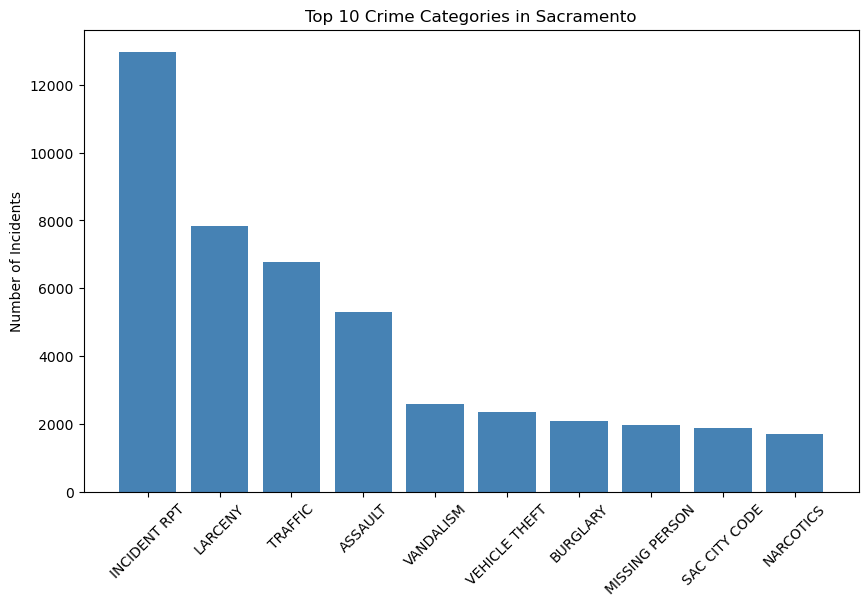

In [4]:
# Visualize top 10 offenses
plt.figure(figsize=(10,6))
plt.bar(top_offenses['Offense_Category'], top_offenses['total_incidents'], color='steelblue')
plt.xticks(rotation=45)
plt.ylabel("Number of Incidents")
plt.title("Top 10 Crime Categories in Sacramento")
plt.show()

The most common crime is miscellaneous. The next top three are larceny, traffic, and assault. They drop off steeply. From there, the next top crimes decrease in count fairly slowly. Next, we'll visualize incidents per month.

In [14]:
# Store hour and date information. Then, reformat for SQL query.
df['Occurrence_Date_PT'] = pd.to_datetime(df['Occurrence_Date_PT'])
df['hour'] = df['Occurrence_Date_PT'].dt.hour
df['date_only'] = df['Occurrence_Date_PT'].dt.date
df['month'] = df['Occurrence_Date_PT'].dt.month
df['Weekend'] = df['Occurrence_Date_PT'].dt.weekday >= 5
df['day_name'] = df['Occurrence_Date_PT'].dt.day_name()

df['Occurrence_Date_PT_reformatted'] = df['Occurrence_Date_PT'].dt.strftime('%Y-%m-%d')
df.to_sql("crime_reports", conn, if_exists="replace", index=False)

58031

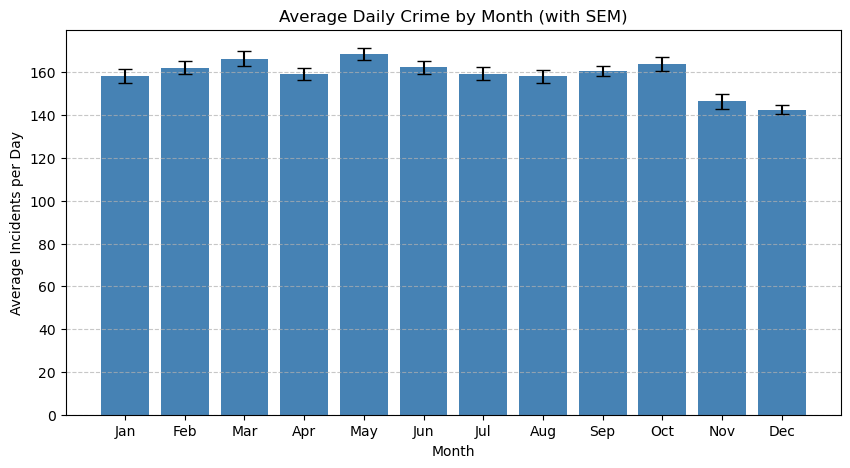

In [6]:
# Visualize monthly incidents
daily_counts = (
    df.groupby(['date_only', 'month'])
      .size()
      .reset_index(name='incidents')
)

monthly_stats = (
    daily_counts.groupby('month')['incidents']
    .agg(['mean', 'sem'])
    .reset_index()
)

monthly_stats['month_name'] = monthly_stats['month'].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(10,5))

plt.bar(
    monthly_stats['month_name'],
    monthly_stats['mean'],
    yerr=monthly_stats['sem'],
    capsize=5,
    color='steelblue'
)

plt.xlabel("Month")
plt.ylabel("Average Incidents per Day")
plt.title("Average Daily Crime by Month (with SEM)")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

It seems from this plot that less incidents occur in November and December compared to the rest of the months of the year. Let's run ANOVA and then Tukey HSD to see if this is significant.

In [8]:
# List of groups (one for each month)
groups = [
    daily_counts[daily_counts['month'] == month]['incidents']
    for month in range(1,13)
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_value:.4f}")

tukey = pairwise_tukeyhsd(
    endog=daily_counts['incidents'],
    groups=daily_counts['month'],
    alpha=0.05
)

print(tukey)

F-statistic: 6.37
p-value: 0.0000
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2   3.8237 0.9992 -10.3194  17.9669  False
     1      3   7.9677  0.757  -5.8112  21.7466  False
     1      4   0.9118    1.0 -12.9814  14.8051  False
     1      5  10.1935  0.386  -3.5854  23.9725  False
     1      6   3.9452 0.9987  -9.9481  17.8384  False
     1      7      1.0    1.0 -12.7789  14.7789  False
     1      8  -0.2581    1.0  -14.037  13.5208  False
     1      9   2.0785    1.0 -11.8148  15.9717  False
     1     10   5.6774 0.9708  -8.1015  19.4563  False
     1     11 -11.9215 0.1748 -25.8148   1.9717  False
     1     12 -15.7419 0.0107 -29.5208   -1.963   True
     2      3    4.144 0.9983  -9.9992  18.2872  False
     2      4  -2.9119 0.9999 -17.1665  11.3427  False
     2      5   6.3698 0.9447  -7.7733   20.513  False
     2      6   0.1214    1.0 -

From ANOVA, we learned that there is a significant difference. Tukey HSD tells us where that significant difference is. Sure enough, November and December are significantly different than almost every other month. We now can confidently say that the crime rate is lower in November and December. Now let's look at weekday vs weekend crime.

In [9]:
# SQL query: weekday vs weekend
query3 = """
SELECT 
    CASE WHEN CAST(STRFTIME('%w', Occurrence_Date_PT) AS INTEGER) IN (0,6) THEN 'Weekend' ELSE 'Weekday' END AS day_type,
    COUNT(*) AS incidents
FROM crime_reports
GROUP BY day_type;
"""

weekday_weekend = pd.read_sql_query(query3, conn)

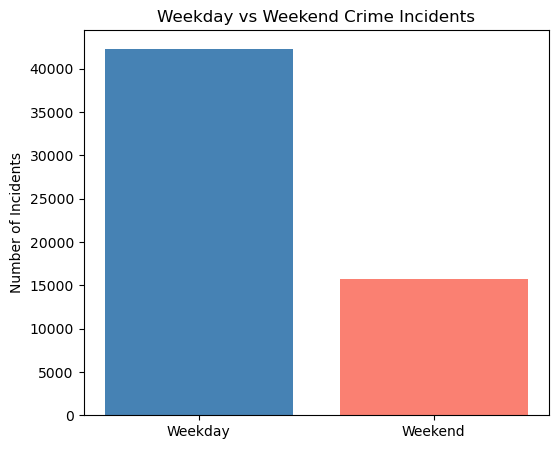

In [10]:
# Visualize weekday vs weekend
plt.figure(figsize=(6,5))
plt.bar(weekday_weekend['day_type'], weekday_weekend['incidents'], color=['steelblue','salmon'])
plt.ylabel("Number of Incidents")
plt.title("Weekday vs Weekend Crime Incidents")
plt.show()

More crimes occur on the weekdays, but there are also more weekdays than weekend days. For a more robust analysis, we look at crime by hour on weekdays and weekends both raw and normalized.

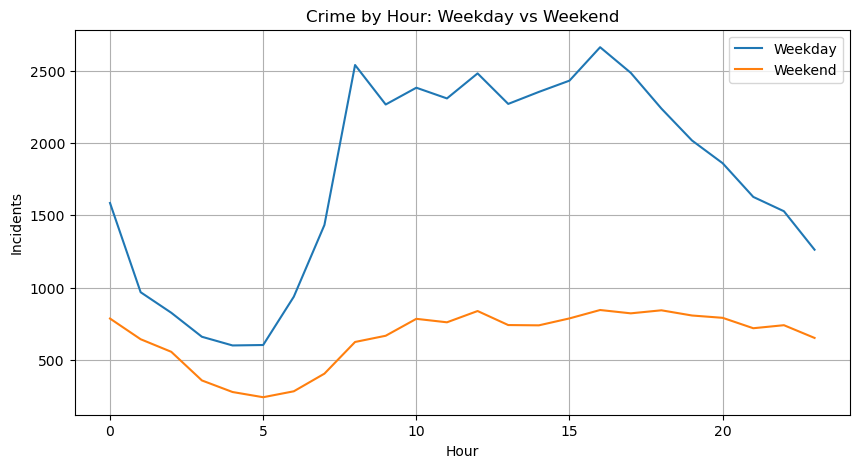

In [11]:
hour_weekend = pd.read_sql_query("""
SELECT 
    hour,
    CASE 
        WHEN CAST(STRFTIME('%w', Occurrence_Date_PT) AS INTEGER) IN (0,6)
        THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,
    COUNT(*) AS incidents
FROM crime_reports
GROUP BY hour, day_type
ORDER BY hour;
""", conn)

weekday = hour_weekend[hour_weekend['day_type'] == 'Weekday']
weekend = hour_weekend[hour_weekend['day_type'] == 'Weekend']

plt.figure(figsize=(10,5))
plt.plot(weekday['hour'], weekday['incidents'], label='Weekday')
plt.plot(weekend['hour'], weekend['incidents'], label='Weekend')

plt.xlabel("Hour")
plt.ylabel("Incidents")
plt.title("Crime by Hour: Weekday vs Weekend")
plt.legend()
plt.grid(True)
plt.show()

Weekday crime peaks in the morning and remains high until the afternoon, where it starts falling roughly linearly until it reaches a trough at the early hours of the morning. Weekend crime, on the other hand, has a less dramatic peak structure and remains higher later in the day. It has the same trough at the early hours of the morning as weekday crime.

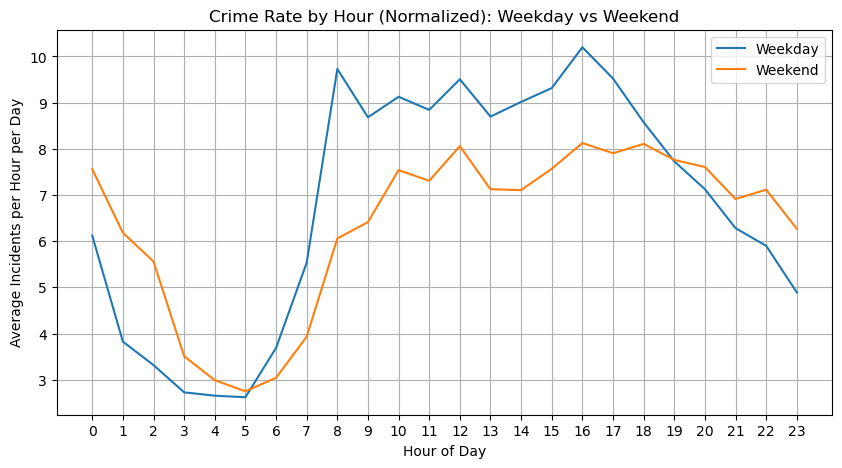

In [12]:
daily_hourly = (
    df.groupby(['date_only', 'hour', 'Weekend'])
      .size()
      .reset_index(name='incidents')
)
hourly_rates = (
    daily_hourly.groupby(['hour', 'Weekend'])['incidents']
    .mean()
    .reset_index()
)
weekday = hourly_rates[hourly_rates['Weekend'] == False]
weekend = hourly_rates[hourly_rates['Weekend'] == True]

plt.figure(figsize=(10,5))

plt.plot(weekday['hour'], weekday['incidents'], label='Weekday')
plt.plot(weekend['hour'], weekend['incidents'], label='Weekend')

plt.xlabel("Hour of Day")
plt.ylabel("Average Incidents per Hour per Day")
plt.title("Crime Rate by Hour (Normalized): Weekday vs Weekend")

plt.xticks(range(0,24))
plt.legend()
plt.grid(True)

plt.show()

When looking at average incidents per hour per day, we see that weekends have higher values at night than weekdays. The patterns like the trough in the early morning from the raw data plot persist. Now let's look at each day of the week specifically to determine if there is any significant difference in number of incidents based on the day of the week.

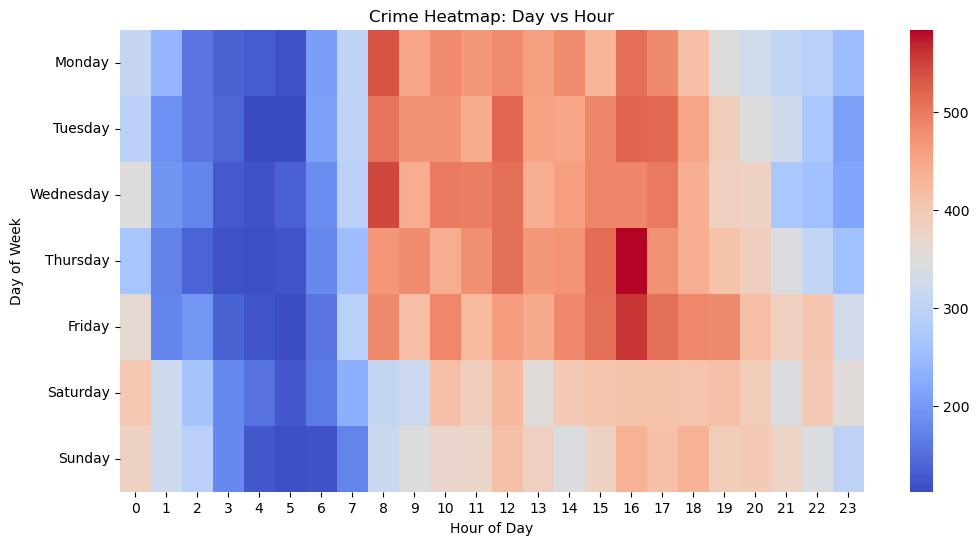

In [15]:
heatmap_data = (
    df.groupby(['day_name', 'hour'])
      .size()
      .unstack(fill_value=0)
)

# Order days properly
heatmap_data = heatmap_data.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='coolwarm')

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Crime Heatmap: Day vs Hour")

plt.show()

It appears like the most crime occurs on the weekdays in the middle of the day, and the least amount of crime occurs in the early hours of the morning. Let's now look at average crime for each day of the week.

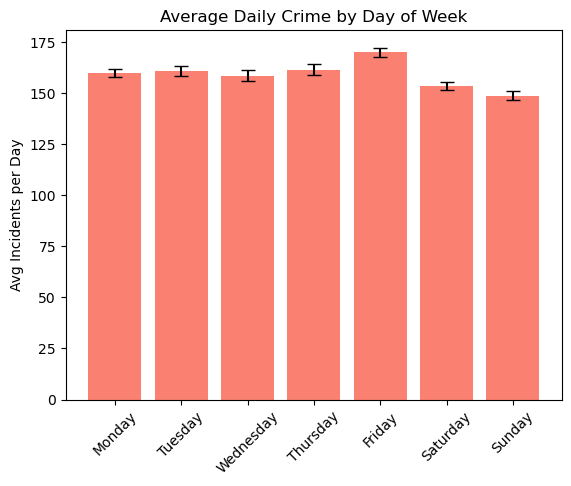

In [16]:
day_counts = df['day_name'].value_counts().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

daily_counts = (
    df.groupby(['date_only', 'day_name'])
      .size()
      .reset_index(name='incidents')
)

stats = (
    daily_counts.groupby('day_name')['incidents']
    .agg(['mean', 'sem'])
)

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
stats = stats.reindex(order)

day_rates = daily_counts.groupby('day_name')['incidents'].mean()

day_rates = day_rates.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

plt.bar(
    stats.index,
    stats['mean'],
    yerr=stats['sem'],
    capsize=5,
    color='salmon'
)
plt.ylabel("Avg Incidents per Day")
plt.title("Average Daily Crime by Day of Week")
plt.xticks(rotation=45)
plt.show()

The error bars on this chart are standard error of the mean. It looks like Friday and Sunday are the highest and lowest crime days of the week, respectively. Let's run ANOVA and Tukey HSD to see if there is a significant difference here.

In [17]:
groups = [
    daily_counts[daily_counts['day_name'] == day]['incidents']
    for day in order
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value}")

tukey = pairwise_tukeyhsd(
    endog=daily_counts['incidents'],
    groups=daily_counts['day_name'],
    alpha=0.05
)

print(tukey)

F-statistic: 8.197565884339452
p-value: 2.5313244500033084e-08
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2  meandiff p-adj   lower    upper   reject
-----------------------------------------------------------
  Friday    Monday  -9.9231 0.0439 -19.6964  -0.1498   True
  Friday  Saturday    -16.5    0.0 -26.2733  -6.7267   True
  Friday    Sunday -21.2308    0.0 -31.0041 -11.4575   True
  Friday  Thursday  -8.3846  0.147 -18.1579   1.3887  False
  Friday   Tuesday  -9.2115 0.0795 -18.9849   0.5618  False
  Friday Wednesday -11.2816 0.0115 -21.0087  -1.5545   True
  Monday  Saturday  -6.5769 0.4194 -16.3502   3.1964  False
  Monday    Sunday -11.3077 0.0119  -21.081  -1.5344   True
  Monday  Thursday   1.5385 0.9992  -8.2349  11.3118  False
  Monday   Tuesday   0.7115    1.0  -9.0618  10.4849  False
  Monday Wednesday  -1.3585 0.9996 -11.0856   8.3686  False
Saturday    Sunday  -4.7308 0.7823 -14.5041   5.0425  False
Saturday  Thursday   8.1154 0.1765  -

Friday and Sunday are both significantly different than most other days of the week. Thus, we may conclude that there are typically more incidents on Fridays and less incidents on Sundays than what is typical.